In [9]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
train_dir = "../datasets/sign_language_detection/Train/"
test_dir = "../datasets/sign_language_detection/Test/"
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2
seed = 123
epochs = 10

In [11]:
classes = sorted(
    [folder for folder in os.listdir(train_dir) 
     if os.path.isdir(os.path.join(train_dir, folder))],
    key=lambda x: int(x)
)

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37']
Number of classes: 38


In [12]:
total_images = 0

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    num_images = len(os.listdir(cls_path))
    total_images += num_images
    print(f"{cls}: {num_images} images")

print("Total images:", total_images)
print("Average per class:", total_images / len(classes))

0: 293 images
1: 294 images
2: 298 images
3: 286 images
4: 246 images
5: 294 images
6: 291 images
7: 289 images
8: 297 images
9: 292 images
10: 298 images
11: 291 images
12: 284 images
13: 286 images
14: 277 images
15: 294 images
16: 298 images
17: 293 images
18: 294 images
19: 295 images
20: 293 images
21: 293 images
22: 300 images
23: 292 images
24: 297 images
25: 294 images
26: 292 images
27: 293 images
28: 291 images
29: 292 images
30: 292 images
31: 295 images
32: 288 images
33: 295 images
34: 290 images
35: 286 images
36: 289 images
37: 296 images
Total images: 11058
Average per class: 291.0


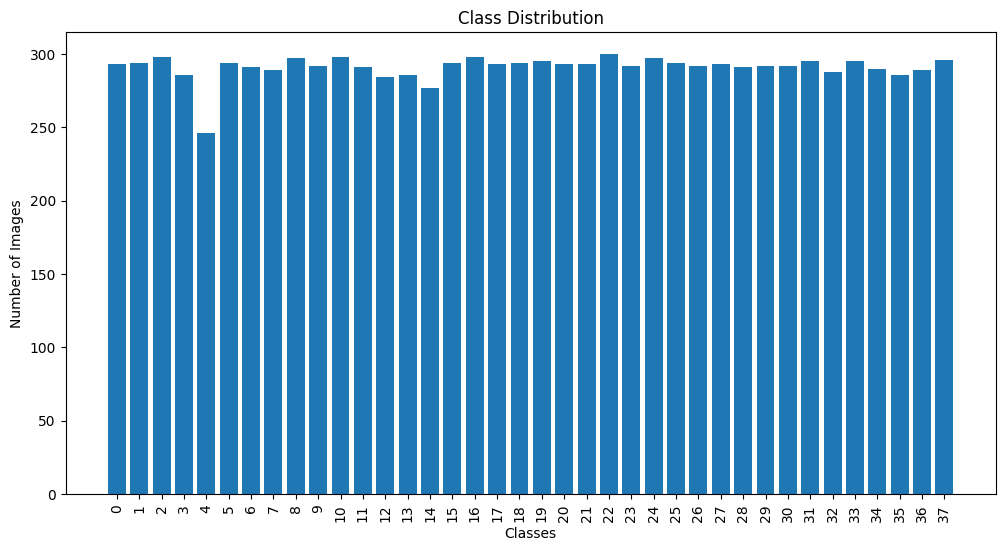

In [13]:
import matplotlib.pyplot as plt

class_counts = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    num_images = len(os.listdir(cls_path))
    class_counts.append(num_images)

plt.figure(figsize=(12,6))
plt.bar(classes, class_counts)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=90)
plt.show()

In [14]:
from PIL import Image
img = Image.open('../datasets/sign_language_detection/Test/20180625_203333.jpg')  # Replace with your image path
print("Original size:", img.size)

Original size: (224, 224)


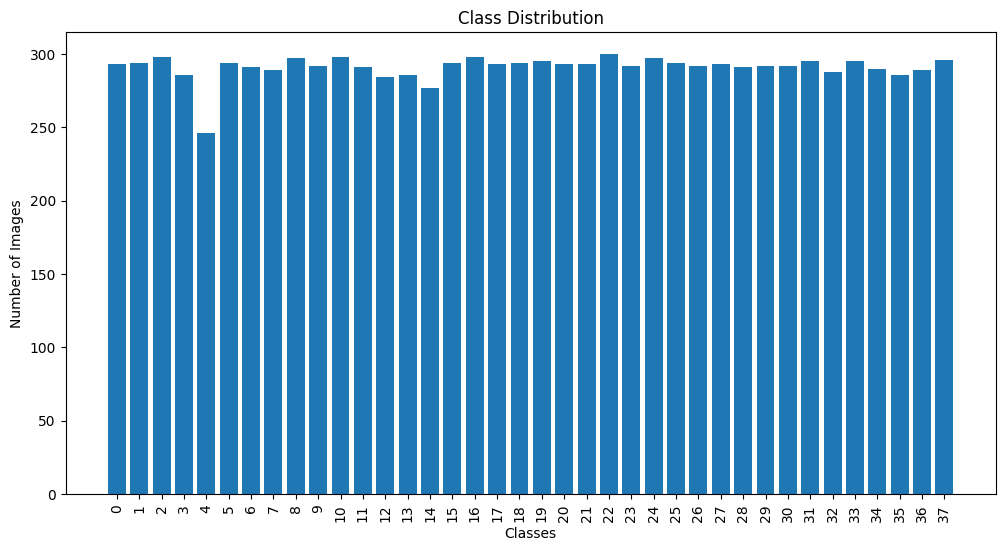

In [15]:
import matplotlib.pyplot as plt

class_counts = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    num_images = len(os.listdir(cls_path))
    class_counts.append(num_images)

plt.figure(figsize=(12,6))
plt.bar(classes, class_counts)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=90)
plt.show()

In [16]:
import os
from PIL import Image

def check_corrupted_images(directory):
    corrupted = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif")):
                path = os.path.join(root, file)
                try:
                    with Image.open(path) as img:
                        img.verify()  # Verify image integrity
                except Exception as e:
                    corrupted.append((path, str(e)))
    return corrupted

# Change this path to the directory you want to check:
dir_to_check = '../datasets/sign_language_detection/Test'
corrupted_images = check_corrupted_images(dir_to_check)

if corrupted_images:
    print(f"Found {len(corrupted_images)} corrupted images:")
    for path, error in corrupted_images:
        print(f"{path}: {error}")
else:
    print("No corrupted images found.")

No corrupted images found.
